In [1]:
from functools import partial
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.interpolate import InterpolatedUnivariateSpline

In [2]:
import jax
from jax import config, jit
import jax.numpy as jnp
from jax.lax import fori_loop

In [3]:
from scripts.figures import set_rc_parameters
from scripts.potentials import Potential
from scripts.wave_function import wave_function

In [4]:
# Enable double precision
config.update("jax_enable_x64", True)

In [5]:
# Run this cell to turn on customized matplotlib graphics
set_rc_parameters()

## Get deuteron wave function for test integral of $\frac{2}{\pi} \int_0^\infty dk\, k^2\, |\psi_d(k)|^2$

In [6]:
# AV18 potential in 3S1-3D1 channel
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120
potential = Potential(kvnn, '3S1', kmax, kmid, ntot)

# Hamiltonian in units MeV
H_matrix = potential.load_hamiltonian()
psi_unitless = wave_function(H_matrix)  # Weights attached
psi_0_unitless = psi_unitless[:ntot]
psi_2_unitless = psi_unitless[ntot:]
k_array, k_weights = potential.load_mesh()
psi_0_units = psi_0_unitless / jnp.sqrt(k_weights)  # Divide out weights
psi_2_units = psi_2_unitless / jnp.sqrt(k_weights)
psi_squared_units = psi_0_units ** 2 + psi_2_units ** 2

# # Interpolate integrand 2 / \pi * k^2 * \psi(k)
# integrand = InterpolatedUnivariateSpline(k_array, psi_squared_units)

In [7]:
k_jax = jnp.asarray(k_array)
psi_squared_jax = jnp.asarray(psi_squared_units)

@jit
def integrand(k):
    """JAX function for integrand as a function of k."""
    
    return jnp.interp(k, k_jax, psi_squared_jax)

In [8]:
# First check that integrand over the same mesh gives correct normalization
norm = jnp.sum(integrand(k_array) * k_weights)
print(norm)

1.0000000000000004


## MC integration

In [9]:
class UniformSampling:
    
    def __init__(self, integrand, num_samples, sig=1.0):
        
        # Set integrand as instance attribute
        self.integrand = integrand
        self.num_samples = num_samples
        self.sig = sig
        
        self.acc_s = jnp.zeros(num_samples)
        self.x_s = jnp.zeros(num_samples)
        
    @partial(jit, static_argnums=(0,))
    def integrate_uniform_sampling(self, a, b):

        # Get samples over [a, b]
        key = jax.random.PRNGKey(0)
        self.acc_s, self.x_s = self.metropolis_walk_uniform(key, a, b)
        
        # Integrate over the interval [a, b]
        vol = b - a
        integral = vol * jnp.mean(integrand(self.x_s))
        
        return self.acc_s, self.x_s, integral

    @partial(jit, static_argnums=(0,))
    def metropolis_walk_uniform(self, key, a, b):

        key, _ = jax.random.split(key)
        
        # Initial point
        x_o = a + (b - a) * jax.random.uniform(key)
        
        # Loop over number of samples
        x_o, key, self.acc_s, self.x_s = fori_loop(
            0, self.num_samples, self.step_uniform,
            (x_o, key, self.acc_s, self.x_s)
        )
        
        return self.acc_s, self.x_s
        
    @partial(jit, static_argnums=(0,))
    def step_uniform(self, i, loop_carry):
            
        x_o, key, self.acc_s, self.x_s = loop_carry             
        f_o = self.integrand(x_o)
        key, subkey = jax.random.split(key)
        x_n = x_o + self.sig * jax.random.normal(subkey)
        f_n = self.integrand(x_n)

        key, subkey = jax.random.split(key)
        
        # This will accept all samples in [a, b]
        acceptance_ratio = (self.uniform_distribution(x_n, a, b)
                            / self.uniform_distribution(x_o, a, b))
        accept = jnp.minimum(1.0, acceptance_ratio)
        x_o = jnp.where(jax.random.uniform(subkey) < accept, x_n, x_o)
        
        self.acc_s = self.acc_s.at[i].set(accept.astype('float32'))
        self.x_s = self.x_s.at[i].set(x_o)
            
        return x_o, key, self.acc_s, self.x_s
    
    @partial(jit, static_argnums=(0,))
    def uniform_distribution(self, x, a, b):
        """Uniform distribution over [a, b]."""
        
        # Check if a <= x <= b
        cond = jnp.logical_and(x >= a, x <= b)
        
        return jnp.where(cond, 1 / (b - a), 0)

In [10]:
# Work in progress
class GaussianSampling:
    
    def __init__(self, integrand, num_samples, sig=1.0):
        
        # Set integrand as instance attribute
        # self.integrand = integrand
        self.integrand = lambda x, a, b: integrand(x) / self.weight(x, a, b)
        self.num_samples = num_samples
        self.sig = sig
        self.acc_s = jnp.zeros(num_samples)
        self.x_s = jnp.zeros(num_samples)

    @partial(jit, static_argnums=(0,))
    def integrate_metropolis(self, a, b):

        # Get samples over [a, b]
        key = jax.random.PRNGKey(0)
        self.acc_s, self.x_s = self.sample_gaussian(key, a, b)
        
#         integral = jnp.mean(self.integrand(self.x_s)
#                             / self.weight(self.x_s, a, b))
        integral = (jnp.mean(self.integrand(self.x_s, a, b)
                             / self.weight(self.x_s, a, b)))
        
        return self.acc_s, self.x_s, integral

    @partial(jit, static_argnums=(0,))
    def sample_gaussian(self, key, a, b):

        key, _ = jax.random.split(key)
        
        # Initial point
        x_o = a + (b - a) * jax.random.uniform(key)
        
        # Loop over number of samples
        x_o, key, self.acc_s, self.x_s = fori_loop(
            0, self.num_samples, self.step, (x_o, key, self.acc_s, self.x_s)
        )
        
        return self.acc_s, self.x_s
        
    @partial(jit, static_argnums=(0,))
    def step(self, i, loop_carry):
            
        x_o, key, self.acc_s, self.x_s = loop_carry             
        key, subkey = jax.random.split(key)
        x_n = x_o + self.sig * jax.random.normal(subkey)

        key, subkey = jax.random.split(key)
        
        # This will accept based on ratio of \psi_d(x_n)^2 / \psi_d(x_o)^2
        acceptance_ratio = self.weight(x_n, a, b) / self.weight(x_o, a, b)
        acceptance_probability = jnp.minimum(1.0, acceptance_ratio)
        u = jax.random.uniform(subkey)
        accept = u < acceptance_probability
        x_o = jnp.where(accept, x_n, x_o)
        
        self.acc_s = self.acc_s.at[i].set(accept.astype('float32'))
        self.x_s = self.x_s.at[i].set(x_o)
            
        return x_o, key, self.acc_s, self.x_s
    
    @partial(jit, static_argnums=(0,))
    def weight(self, x, a, b):
        """Weight by Gaussian function excluding points outside of [a, b]."""

        sigma = 1.0
        gaussian = (jnp.exp(-x**2 / (2 * sigma ** 2))
                    / jnp.sqrt(2 * jnp.pi * sigma ** 2))
        
        # Check if a <= x <= b
        cond = jnp.logical_and(x >= a, x <= b)
        
        return 2 * jnp.where(cond, gaussian, 0)

### Test for uniform sampling first

Normalization = 1.01420


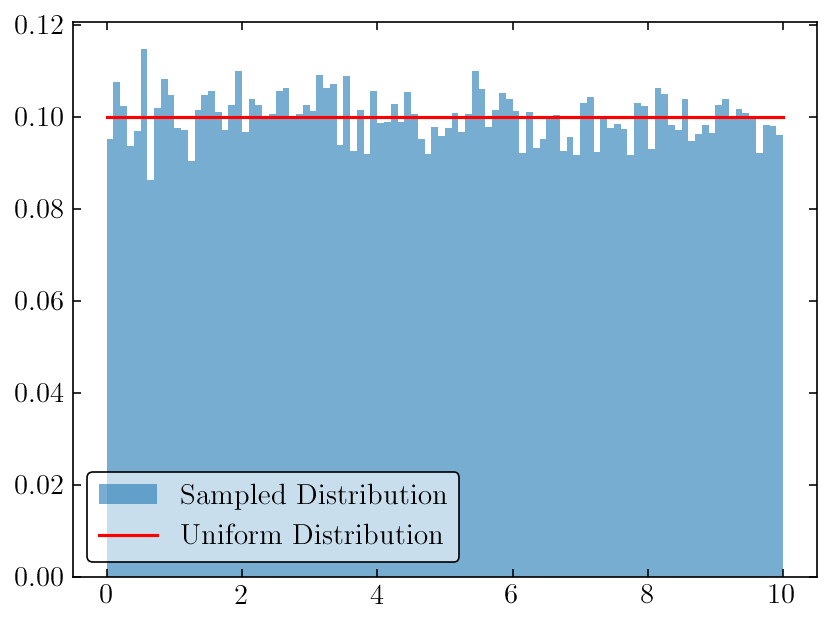

In [25]:
key = jax.random.PRNGKey(0)
a, b = 0, 10.0  # Interval boundaries
sig = (b - a) / 2
num_samples = 100000


mc = UniformSampling(integrand, num_samples, sig=sig)

acc_s, x_s, integral = mc.integrate_uniform_sampling(a, b)

print(f"Normalization = {integral:.5f}")

# Plotting
plt.hist(x_s, bins=100, density=True, alpha=0.6, label="Sampled Distribution")
x = jnp.linspace(a, b, 1000)
plt.plot(x, mc.uniform_distribution(x, a, b), label="Uniform Distribution",
         color='red')
plt.legend()
plt.show()

### Acceptance based on ratio of deuteron wave function $\alpha = \frac{\psi_d(x')^2}{\psi_d(x)^2}$

Normalization = 526.56214


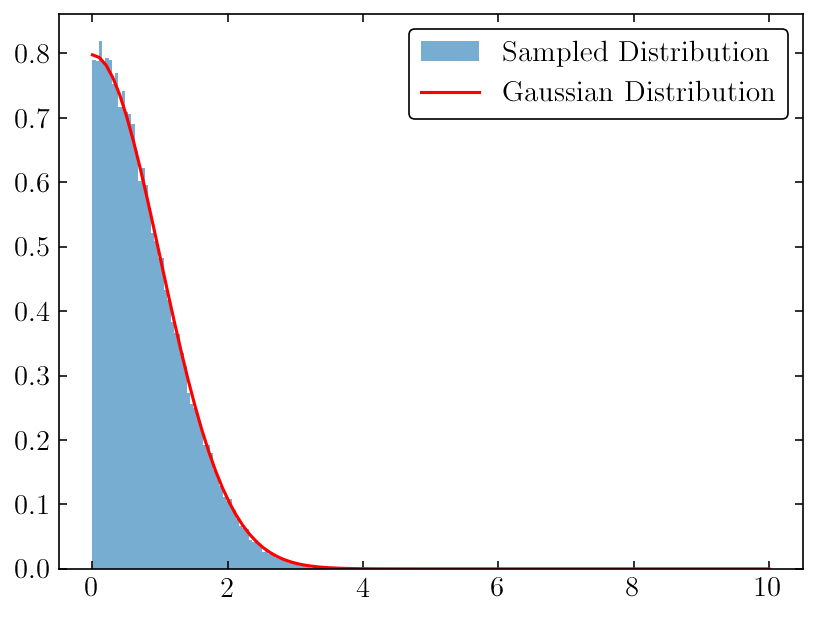

In [12]:
key = jax.random.PRNGKey(0)
a, b = 0, 10.0  # Interval boundaries
num_samples = 100000

mc = GaussianSampling(integrand, num_samples, sig=7/b)

acc_s, x_s, integral = mc.integrate_metropolis(a, b)

print(f"Normalization = {integral:.5f}")

# Plotting
plt.hist(x_s, bins=100, density=True, alpha=0.6, label="Sampled Distribution")
x = jnp.linspace(a, b, 100)
plt.plot(x, mc.weight(x, a, b), label="Gaussian Distribution", color='red')
plt.legend()
plt.show()

In [13]:
print(jnp.mean(acc_s))

0.6095900000000001


In [14]:
test_int = jnp.sum(k_weights * mc.weight(k_array, 0, 15.0))
print(test_int)

0.9999999999999581


In [15]:
for i in x_s:
    print(i)

4.808698629780487
4.808698629780487
4.658010372737198
4.370289573201812
4.370289573201812
3.7093850149787504
3.2303290542310448
3.2303290542310448
3.360748025213489
4.019621779737323
4.486917092981442
4.2437284062606055
3.157615519105127
3.157615519105127
2.475603612201591
2.2136942468910563
2.2136942468910563
2.4259508710683386
1.5792384141139029
1.159238771146929
1.159238771146929
1.159238771146929
1.1772035010751745
0.2944078509345107
0.12433876970323879
0.12433876970323879
0.32928801529148477
0.008130765539911648
0.008130765539911648
0.70123295430938
0.5247902142326967
0.7366981427536081
1.4426160618771218
0.9090332770226655
0.9317052282555868
0.4643536019489667
0.6254913251199921
0.6254913251199921
0.309918747702882
0.14725480453383896
0.14725480453383896
0.14725480453383896
0.14725480453383896
0.5669136046443278
0.9544325246545672
0.8947176818414363
0.9282535311696791
1.0464772241724105
0.4733346874021094
0.4733346874021094
1.354520986296908
1.354520986296908
1.5984236084233452
0

0.061656162705800065
0.061656162705800065
0.7711620260154042
0.20004680318013118
1.1046967467456783
0.5287320098522835
0.16027520787543478
0.16027520787543478
0.6929875078781154
0.6929875078781154
0.4258881606260387
0.5120712025219935
0.5120712025219935
0.1298191058738168
0.16721774587607136
0.8271363003811377
0.3916893952055189
0.3916893952055189
0.3916893952055189
0.04669749524344109
0.04669749524344109
0.35831235590976745
0.35831235590976745
0.3891307554275528
0.3891307554275528
0.3891307554275528
0.8954117184805005
0.40061495649590206
0.7884830750418919
0.465556934152191
0.465556934152191
0.465556934152191
0.465556934152191
1.7371482030119414
1.7371482030119414
1.3431570004567095
2.0486819565065297
1.4683233459473848
0.8363424774196605
0.09458226743338186
0.6579312442180467
0.6579312442180467
0.8568450519179132
0.5772516899255428
0.5772516899255428
0.11762571527420267
1.7195210739125242
1.8027444185283503
1.8808033644270634
1.1899867888154005
0.2213077167117823
0.2213077167117823
0

0.8024700475243999
1.4045537234797292
1.7668412952079513
1.3274657207897542
1.5891580365699236
1.5891580365699236
1.9570062821195322
2.2136921373070857
2.2136921373070857
1.367049132242165
0.3654761253736271
0.3654761253736271
0.3654761253736271
0.10787285420740773
0.10787285420740773
0.10787285420740773
0.32426732342769926
0.32426732342769926
0.32426732342769926
0.32426732342769926
0.2697072887318616
1.0144661308938765
1.2802629539400099
1.7182030964722124
1.7182030964722124
1.7182030964722124
1.7182030964722124
1.7182030964722124
1.7182030964722124
1.7543634713206113
1.4450037640872726
1.4450037640872726
0.6586448383129125
0.6586448383129125
0.07249053502167702
0.1759031315621159
0.1759031315621159
0.43604937035127483
0.43604937035127483
0.5764940743961816
0.8168268582541468
0.9015881631361068
0.006203478349540066
0.006203478349540066
0.006203478349540066
0.006203478349540066
0.006203478349540066
0.7888396232229755
1.217534211471312
0.4452489504725753
0.4452489504725753
0.44344621950

0.7245983111475679
0.1668654740435881
0.8568651019739401
1.4510664210062025
1.0599756968792673
1.0599756968792673
1.6586136499235646
1.6586136499235646
0.8818877936168631
0.6016209544597224
0.30639501421267634
0.30639501421267634
0.30639501421267634
0.187727154926999
0.31822231100023274
0.31822231100023274
0.8658382896925515
0.5787953671587333
0.22735397958567016
0.9666072807393778
1.7110042177275278
1.1591640734786055
0.6610654383444922
0.6610654383444922
0.6610654383444922
0.6610654383444922
0.6610654383444922
0.6610654383444922
0.9845766309826472
0.6442993225493595
0.6442993225493595
0.3242392764764373
0.33265991665565825
0.33265991665565825
0.6398867590578085
1.310751613450491
1.2877215860666031
1.2877215860666031
1.572504358207224
1.3119476726061814
0.19920070747014296
0.19920070747014296
0.33842177148447183
0.33842177148447183
0.33842177148447183
0.10055139758365471
0.4051714641311583
1.1203365758878434
0.21734041118500974
0.21734041118500974
0.21734041118500974
0.217340411185009

2.0059579283465316
2.9695109354232874
2.569818420675681
2.2320950780728874
2.2361328447609123
1.9092756282051733
1.9092756282051733
0.7853945328950516
0.7853945328950516
0.43090719625573115
0.43090719625573115
0.43090719625573115
0.8465642914779413
0.8094836915736628
1.5173714613647813
1.9632354466919562
1.5032056497829065
1.4781332441851975
1.4781332441851975
1.5103941564792658
0.6201529811618799
0.08910027566416431
0.08910027566416431
0.08910027566416431
0.08910027566416431
0.08910027566416431
0.08910027566416431
0.4193353987312622
0.4193353987312622
0.4193353987312622
0.4193353987312622
0.3799346621802595
0.4499650457919903
0.4499650457919903
0.09136993068843682
0.2660505046505287
0.2660505046505287
1.1626002656590686
0.43939683300718135
0.43939683300718135
0.43939683300718135
1.2805982656779695
1.2805982656779695
1.2805982656779695
1.2805982656779695
1.2805982656779695
0.7479768909731953
1.0345559033926688
0.9419116544510386
0.9419116544510386
0.9419116544510386
0.8874404376207344


0.20315910456765202
1.4663257538648344
1.4663257538648344
0.8903674052920205
1.0492587108375044
0.32851022454300915
0.555515043614737
1.4554948820571791
0.6773439661894238
0.6773439661894238
0.6889610837884704
0.6889610837884704
0.004535845203063992
0.18260161343859652
0.559247550481658
0.559247550481658
0.559247550481658
0.33176869922737007
0.4288768732449334
0.4288768732449334
1.0503247703084955
0.8553477388192374
1.2527733215217025
1.1379559430372796
0.875208526890071
0.875208526890071
0.875208526890071
0.875208526890071
0.875208526890071
0.875208526890071
0.875208526890071
0.875208526890071
0.875208526890071
0.8233707388545444
0.8233707388545444
0.8233707388545444
0.8233707388545444
0.6967169053041208
0.6967169053041208
0.6967169053041208
0.6967169053041208
0.6405009832167771
0.1305743568945399
0.1305743568945399
0.1305743568945399
0.1305743568945399
0.2843013121489287
0.2843013121489287
0.2843013121489287
0.42121565045308335
0.2378381731838958
0.28991688161510565
0.191122667696893

0.9774586398722847
1.1916441435687652
1.182274669967373
0.7627633419983669
0.009656553762312163
0.009656553762312163
0.03438824829221195
1.3079357800439209
0.359666888563314
0.5441585493282775
0.0302894444026207
0.0302894444026207
0.0302894444026207
0.2753182380956706
0.03450964426146845
0.03450964426146845
0.43668792771335707
0.43668792771335707
0.43668792771335707
1.2815015172675757
1.5549218914076708
0.6627399260399519
0.6627399260399519
0.6627399260399519
0.6627399260399519
0.6627399260399519
0.25431780757537237
0.25431780757537237
0.25431780757537237
0.4922006066674967
0.0066425901343162095
0.9422355592192828
1.0808907127318443
1.1724399938630168
1.1724399938630168
1.4915510921458708
1.4915510921458708
1.4915510921458708
1.674293491482685
1.674293491482685
1.6443375848966546
1.5056480154818712
2.0668699647671676
2.0668699647671676
0.9412310392856419
0.9412310392856419
0.46317612310131684
0.46317612310131684
0.03701878198627942
0.19820933352181097
0.19820933352181097
0.683677717526

1.5578798545163859
1.5840459458271883
1.3592580161306878
1.3592580161306878
1.4497521604399495
1.192893759411643
0.9568808227943835
0.9568808227943835
1.1029368360120977
1.0614053652818305
1.0614053652818305
1.1299987344591673
0.5066180306715407
0.5066180306715407
0.5066180306715407
0.25011067912854795
0.06395546041968211
0.06395546041968211
0.06395546041968211
0.06395546041968211
0.04742725501857671
0.2963767365824715
0.2963767365824715
0.5982787227450277
0.30305787879883966
0.30305787879883966
0.30410686163423306
0.4100980888784179
0.4100980888784179
0.47057652407714823
0.47057652407714823
1.0443204869832023
1.0689352147958127
0.9853762666258867
1.1680427240045423
1.5477281853912894
1.5477281853912894
1.5477281853912894
1.5477281853912894
1.5477281853912894
0.9537243712034085
1.052629486668984
1.052629486668984
1.2202253012682454
0.5843524021372356
0.5843524021372356
0.03324861593682522
0.03324861593682522
0.03324861593682522
0.03324861593682522
0.03324861593682522
0.7085295812937582

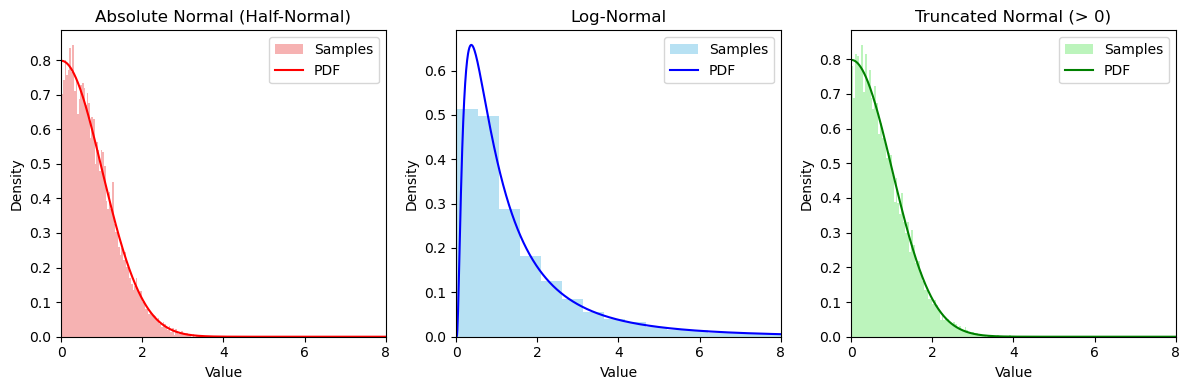

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import halfnorm, lognorm, truncnorm

# Set random seed
rng = np.random.default_rng(seed=0)

# Parameters
mu, sigma = 0.0, 1.0
num_samples = 10000

# Sample distributions
abs_normal_samples = np.abs(rng.normal(loc=mu, scale=sigma, size=num_samples))
log_normal_samples = np.exp(mu + sigma * rng.normal(size=num_samples))

def truncated_normal_positive(size, mu=0.0, sigma=1.0):
    samples = []
    while len(samples) < size:
        x = rng.normal(loc=mu, scale=sigma, size=size)
        samples.extend(x[x > 0])
    return np.array(samples[:size])

trunc_normal_samples = truncated_normal_positive(num_samples)

# X values for PDFs
x = np.linspace(0, 8, 1000)

# Theoretical PDFs
half_normal_pdf = halfnorm(scale=sigma).pdf(x)
log_normal_pdf = lognorm(s=sigma, scale=np.exp(mu)).pdf(x)
trunc_normal_pdf = truncnorm(a=(0 - mu) / sigma, b=np.inf, loc=mu, scale=sigma).pdf(x)

# Plotting
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(abs_normal_samples, bins=100, density=True, alpha=0.6, color='lightcoral', label='Samples')
plt.plot(x, half_normal_pdf, 'r', label='PDF')
plt.title('Absolute Normal (Half-Normal)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(0, 8)
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(log_normal_samples, bins=100, density=True, alpha=0.6, color='skyblue', label='Samples')
plt.plot(x, log_normal_pdf, 'b', label='PDF')
plt.title('Log-Normal')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(0, 8)
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(trunc_normal_samples, bins=100, density=True, alpha=0.6, color='lightgreen', label='Samples')
plt.plot(x, trunc_normal_pdf, 'g', label='PDF')
plt.title('Truncated Normal (> 0)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(0, 8)
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
import jax
nsamples, ndim = 100, 3
key = jax.random.PRNGKey(0)
samples = jax.random.uniform(key, shape=(nsamples,ndim))
print(samples)

[[3.71822596e-01 8.31389427e-03 7.01019168e-01]
 [9.96834993e-01 9.32080507e-01 3.09046984e-01]
 [5.96987605e-01 8.30902457e-01 9.94125009e-01]
 [6.41379476e-01 5.73655844e-01 6.26451969e-01]
 [9.27416325e-01 8.10644627e-01 3.40708613e-01]
 [2.89981365e-01 2.53642559e-01 1.49463654e-01]
 [9.03167009e-01 1.54283285e-01 9.38482523e-01]
 [1.80904508e-01 6.31375313e-02 2.09410429e-01]
 [8.63922834e-01 1.29163265e-03 3.04615498e-03]
 [2.52388239e-01 6.39620543e-01 6.17850661e-01]
 [3.91263962e-02 8.91221762e-02 2.58434534e-01]
 [7.13822246e-01 6.02691174e-01 5.65214038e-01]
 [5.53673983e-01 3.08219790e-01 9.52386379e-01]
 [5.08308411e-01 1.58028126e-01 2.85910964e-01]
 [2.83860087e-01 6.60703778e-01 7.57087231e-01]
 [5.33252954e-02 5.81324577e-01 8.46078277e-01]
 [2.48372555e-02 5.18801928e-01 1.19519234e-03]
 [7.45087981e-01 4.33419704e-01 5.40726423e-01]
 [6.24194741e-01 4.73781586e-01 9.77716446e-01]
 [4.16373253e-01 4.96654630e-01 6.26257658e-02]
 [8.31938982e-01 1.76963449e-01 2.316851